In [2]:
import pytometry as pm
import anndata as ad
import scanpy as sc
import numpy as np
import pandas as pd
import seaborn as sb

from sklearn.neighbors import KernelDensity
from scipy.spatial.distance import cdist

import matplotlib.pyplot as pl
from matplotlib import rcParams
from matplotlib import colors

import os
import datetime

import fcsparser

sc.settings.verbosity = 3

In [2]:
now = datetime.datetime.now()
today = now.strftime("%Y%m%d")

In [3]:
data_path = "/public/users/xueyupeng/VZV/lvzhu/"

In [12]:
fcs_files = []

for root, dirs, files in os.walk(data_path):
    # 只在路径中包含 separate 的目录中找 fcs
    if os.path.basename(root) == "separate":
        for file in files:
            if file.endswith(".fcs"):
                fcs_files.append(os.path.join(root, file))

print(len(fcs_files))
fcs_files[:5]

156


['/public/users/xueyupeng/VZV/lvzhu/20260129/separate/A004-V1_20260129-1_2-3.fcs',
 '/public/users/xueyupeng/VZV/lvzhu/20260129/separate/A007-V0_20260129-2_5-3.fcs',
 '/public/users/xueyupeng/VZV/lvzhu/20260129/separate/A016-V1_20260129-4_6-3.fcs',
 '/public/users/xueyupeng/VZV/lvzhu/20260129/separate/A007-V3_20260129-2_7-3.fcs',
 '/public/users/xueyupeng/VZV/lvzhu/20260129/separate/A005-V4_20260129-1_8-3.fcs']

In [14]:
import fcsparser

In [ ]:
files_all = os.listdir(data_path)
files = [fileID for fileID in files_all if fileID.endswith(".fcs")]

for f in files:
    file_path = os.path.join(data_path, f)
    try:
        # 读取 fcs 文件，返回metadata和data（DataFrame）
        meta, data = fcsparser.parse(file_path, reformat_meta=True)
        cell_count = data.shape[0]  # 行数即为细胞数量（事件数）
        print(f"{f}: {cell_count} cells")
    except Exception as e:
        print(f"无法读取文件 {f}: {e}")

In [4]:
expected_files = []
for num in range(1, 377):
    for suffix in ['B1', 'B2']:
        # 生成基础文件名（不包含额外数字后缀）
        base_name = f"BaseFileName_FB{num:03d}_{suffix}"
        # 检查实际文件名列表中是否存在以这个基础文件名开头的文件
        found = False
        for actual_file in files:
            if actual_file.startswith(base_name) and actual_file.endswith('.fcs'):
                found = True
                break
        if not found:
            # 如果没有找到对应的实际文件，将其添加到缺失文件列表中
            expected_files.append(f"{base_name}.fcs")

# 找出缺失的文件
missing_files = set(expected_files)

# 对缺失的文件按照文件名中的数字大小（FB大小）进行排序
sorted_missing_files = sorted(missing_files, key=lambda x: int(x.split("_")[1][2:]))

# 输出按照FB大小排序的缺失文件
print("\n缺失的文件按照FB大小排序：")
print(f"总共缺失 {len(sorted_missing_files)} 个文件：")
for file in sorted_missing_files:
    print(file)


缺失的文件按照FB大小排序：
总共缺失 4 个文件：
BaseFileName_FB134_B2.fcs
BaseFileName_FB134_B1.fcs
BaseFileName_FB146_B2.fcs
BaseFileName_FB146_B1.fcs


In [ ]:
adatas = []
for fileID in files:
    meta_info = fileID.split(".fcs")[0].split("_")
    adata = pm.io.read_fcs(data_path + fileID)
    adata.obs["ID"] = meta_info[1]
    adata.obs["Visit"] = meta_info[2]
    adata.obs["Sample"] = meta_info[1] + "_" + meta_info[2]
    pm.pp.split_signal(adata, var_key="channel",option="element",data_type="cytof")
    adatas.append(adata)

In [6]:
adatas[0].var_names

Index(['209Bi_CD16', '106Cd_CD45', '110Cd_CD45', '111Cd_CD45', '112Cd_CD8',
       '113Cd_CD45', '114Cd_CD45', '116Cd_CD45', '140Ce_EQ1', '161Dy_CD123',
       '162Dy_Ki-67', '163Dy_CXCL10', '164Dy_Arginase-1', '166Er_MCP-1',
       '167Er_CD69', '168Er_m6A', '170Er_CD45RA', '151Eu_EQ3_pS6',
       '153Eu_EQ4_TNF-a', '155Gd_CD14', '156Gd_CD56', '158Gd_TCR-gd',
       '160Gd_CD27', '165Ho_EQ5_IL-6', '115In_CD4', '191Ir_DNA1', '193Ir_DNA2',
       '175Lu_EQ6_pSTAT1', '142Nd_EQ2_IgD', '143Nd_CD1c', '144Nd_IFN-a',
       '145Nd_CXCR3', '146Nd_CXCL9', '148Nd_H3K27ac', '150Nd_CD57',
       '141Pr_CD3', '195Pt_VIABILITY', '147Sm_CD86', '149Sm_IL-1b',
       '152Sm_CCR2', '154Sm_IL-4', '159Tb_CD38', '169Tm_GranzymeB',
       '171Yb_HLA-DR', '172Yb_IFN-g', '173Yb_CD11c', '174Yb_CD19',
       '176Yb_EQ7_pSTAT3'],
      dtype='object')

In [7]:
adata_all = ad.AnnData.concatenate(*adatas, join="outer", uns_merge="unique")

/tmp/ipykernel_1934689/2282619525.py:1: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  adata_all = ad.AnnData.concatenate(*adatas, join="outer", uns_merge="unique")


In [8]:
marker_list = adata_all.var["marker"].values

In [9]:
marker_list

['106Cd_CD45', '110Cd_CD45', '111Cd_CD45', '112Cd_CD8', '113Cd_CD45', ..., '176Yb_EQ7_pSTAT3', '191Ir_DNA1', '193Ir_DNA2', '195Pt_VIABILITY', '209Bi_CD16']
Length: 48
Categories (48, object): ['106Cd_CD45', '110Cd_CD45', '111Cd_CD45', '112Cd_CD8', ..., '191Ir_DNA1', '193Ir_DNA2', '195Pt_VIABILITY', '209Bi_CD16']

In [ ]:
rename_dict = {}
for marker in marker_list:
    elem_info = marker.split("_")
    rename_dict[marker] = elem_info[-1] if len(elem_info) > 1 else "unused"
rename_dict

In [11]:
adata_all.var["AB"] = pd.Categorical(adata_all.var["marker"]).map(rename_dict)

/tmp/ipykernel_1934689/544028101.py:1: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  adata_all.var["AB"] = pd.Categorical(adata_all.var["marker"]).map(rename_dict)


In [12]:
marker_keep = [marker for marker in adata_all.var["AB"] if marker not in ["unused", "CD45", "EQ1"]]
print(len(marker_keep))
marker_keep

41


['CD8',
 'CD4',
 'CD3',
 'IgD',
 'CD1c',
 'IFN-a',
 'CXCR3',
 'CXCL9',
 'CD86',
 'H3K27ac',
 'IL-1b',
 'CD57',
 'pS6',
 'CCR2',
 'TNF-a',
 'IL-4',
 'CD14',
 'CD56',
 'TCR-gd',
 'CD38',
 'CD27',
 'CD123',
 'Ki-67',
 'CXCL10',
 'Arginase-1',
 'IL-6',
 'MCP-1',
 'CD69',
 'm6A',
 'GranzymeB',
 'CD45RA',
 'HLA-DR',
 'IFN-g',
 'CD11c',
 'CD19',
 'pSTAT1',
 'pSTAT3',
 'DNA1',
 'DNA2',
 'VIABILITY',
 'CD16']

In [13]:
adata_all = adata_all[:, np.in1d(adata_all.var["AB"], marker_keep)]
adata_all.obs["Sample"].value_counts()

Sample
FB371_B1    760514
FB021_B1    610264
FB209_B1    608979
FB208_B1    593945
FB375_B1    561171
             ...  
FB123_B2     18474
FB237_B2     17808
FB136_B2     16867
FB326_B2     16295
FB228_B2     15764
Name: count, Length: 748, dtype: int64

In [ ]:
adata_all

In [69]:
# Downsampling to 5k cells/sample
from tqdm import tqdm

sample_key = 'Sample'

print("原始数据样本分布:")
print(adata_all.obs[sample_key].value_counts())

max_cells_per_sample = 5000

sampled_indices = []
sample_ids = adata_all.obs[sample_key].unique()
# 对每个样本进行下采样
for sample in tqdm(sample_ids, desc="下采样进度"):
    # 获取当前样本的所有细胞索引
    sample_mask = adata_all.obs[sample_key] == sample
    sample_indices = np.where(sample_mask)[0]
    
    # 如果样本细胞数超过max_cells_per_sample，则随机下采样
    if len(sample_indices) > max_cells_per_sample:
        sampled_indices.extend(np.random.choice(sample_indices, 
                                              size=max_cells_per_sample, 
                                              replace=False))
    else:
        sampled_indices.extend(sample_indices)

adata_downsampled = adata_all[sampled_indices, :].copy()

原始数据样本分布:
Sample
FB371_B1    760514
FB021_B1    610264
FB209_B1    608979
FB208_B1    593945
FB375_B1    561171
             ...  
FB123_B2     18474
FB237_B2     17808
FB136_B2     16867
FB326_B2     16295
FB228_B2     15764
Name: count, Length: 748, dtype: int64


下采样进度: 100%|██████████| 748/748 [00:24<00:00, 30.03it/s]


In [ ]:
adata_downsampled

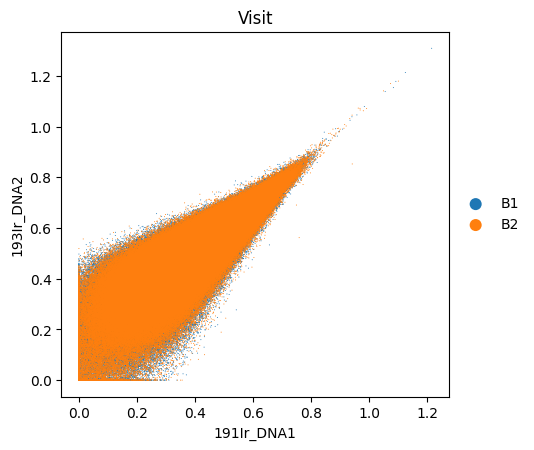

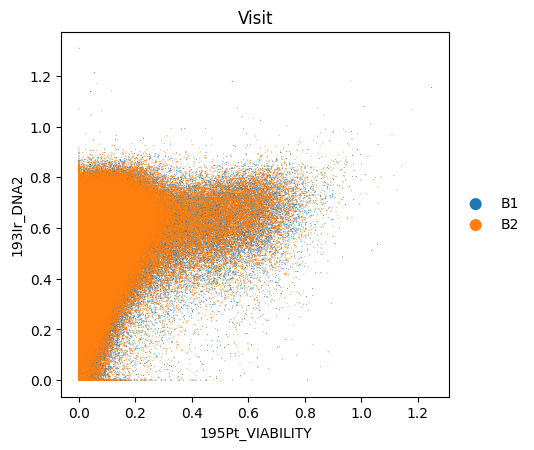

In [71]:
cofactor = 5

adata_downsampled.layers["original"] = adata_downsampled.X
pm.tl.normalize_arcsinh(adata=adata_downsampled, cofactor=cofactor)

rcParams["figure.figsize"] = (5, 5)
sc.pl.scatter(adata_downsampled, x="191Ir_DNA1", y="193Ir_DNA2", color="Visit", size=2)

rcParams["figure.figsize"] = (5, 5)
sc.pl.scatter(adata_downsampled, x="195Pt_VIABILITY", y="193Ir_DNA2", color="Visit", size=2)

In [43]:
colors2 = pl.cm.Reds(np.linspace(0, 1, 80))
colors3 = pl.cm.Greys_r(np.linspace(0.7, 0.8, 10))
#custom_color = '#4A9D47'
#custom_rgba = mcolors.hex2color(custom_color) + (1,)
colorsComb = np.vstack([colors3, colors2]) 
mymap = colors.LinearSegmentedColormap.from_list("my_colormap", colorsComb)

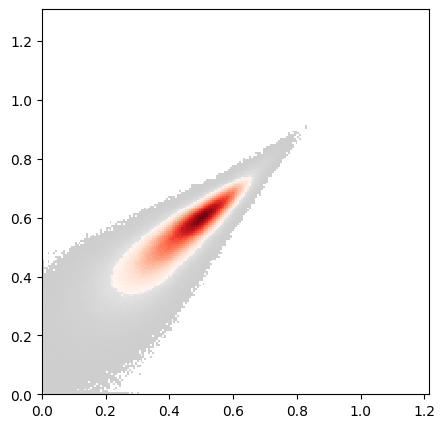

In [73]:
x = adata_downsampled.var["AB"] == "DNA1"
y = adata_downsampled.var["AB"] == "DNA2"

ax = pl.hist2d(
    adata_downsampled.X[:, x].flatten(),
    adata_downsampled.X[:, y].flatten(),
    bins=200,
    cmin=5,
    cmap=mymap,
)
pl.show()

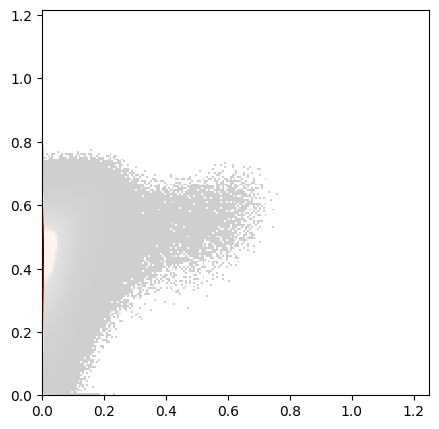

In [74]:
x = adata_downsampled.var["AB"] == "VIABILITY"
y = adata_downsampled.var["AB"] == "DNA1"

ax = pl.hist2d(
    adata_downsampled.X[:, x].flatten(),
    adata_downsampled.X[:, y].flatten(),
    bins=200,
    cmin=5,
    cmap=mymap,
)
pl.show()

In [77]:
dna1_low = (adata_downsampled.X[:, adata_downsampled.var["AB"] == "DNA1"].flatten() < 0.2) | (adata_downsampled.X[:, adata_downsampled.var["AB"] == "DNA1"].flatten() > 0.7)
dna2_low = (adata_downsampled.X[:, adata_downsampled.var["AB"] == "DNA2"].flatten() < 0.3) | (adata_downsampled.X[:, adata_downsampled.var["AB"] == "DNA2"].flatten() > 0.7)
viab_low = adata_downsampled.X[:, adata_downsampled.var["AB"] == "VIABILITY"].flatten() > 0.4

viability_filter = ~(dna1_low | dna2_low | viab_low)

In [1]:
np.sum(viability_filter)

NameError: name 'np' is not defined

In [ ]:
adata_downsampled = adata_downsampled[viability_filter]
adata_downsampled

In [ ]:
viab_marker = ["DNA1", "DNA2", "VIABILITY"]
adata_downsampled = adata_downsampled.copy()
for marker in viab_marker:
    adata_downsampled.obs[marker] = adata_downsampled.X[:, adata_downsampled.var["AB"] == marker].flatten()

adata_downsampled = adata_downsampled[:, np.invert(np.in1d(adata_downsampled.var["AB"], viab_marker))].copy()
adata_downsampled

computing PCA
    with n_comps=40


/public/users/yuxuanjing/.conda/envs/yuxuanjing/lib/python3.12/site-packages/scanpy/preprocessing/_pca.py:314: ImplicitModificationWarning: Setting element `.obsm['X_pca']` of view, initializing view as actual.
  adata.obsm[key_obsm] = X_pca


    finished (0:00:10)


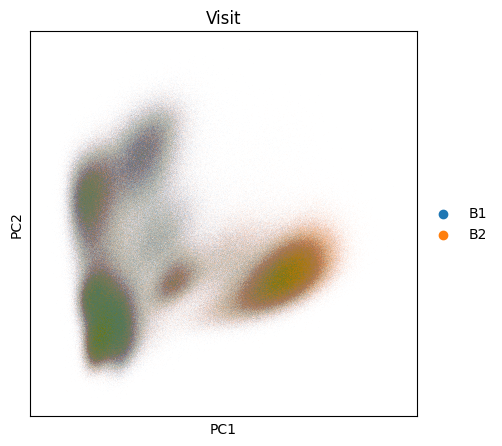

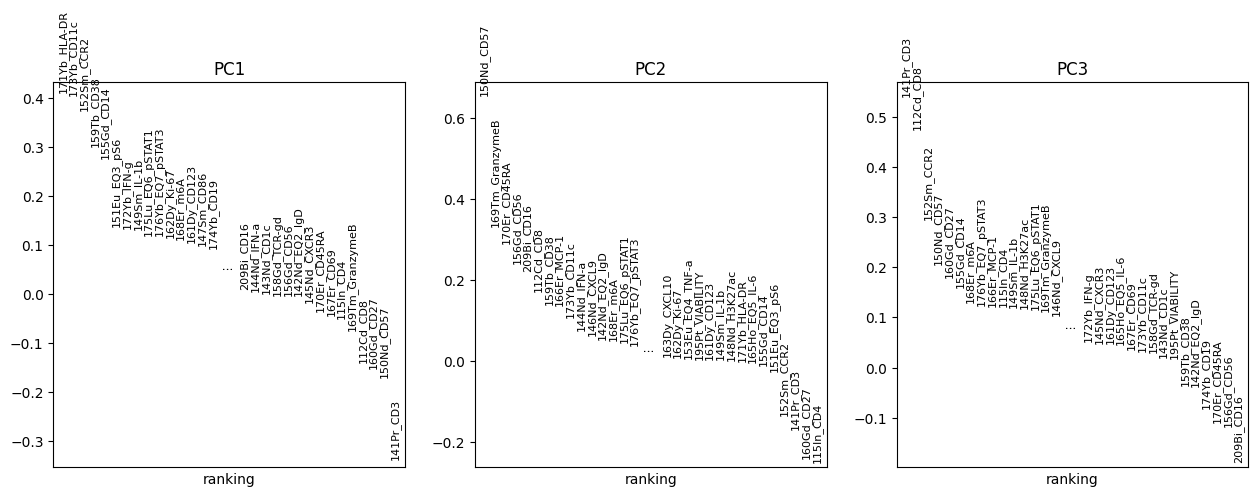

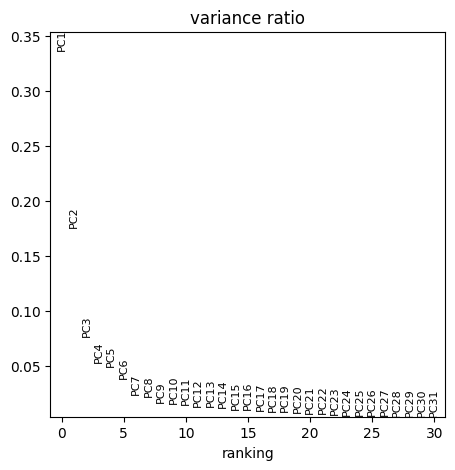

In [80]:
sc.pp.pca(adata_downsampled)
sc.pl.pca_overview(adata_downsampled, color = "Visit")

In [81]:
adata_pcs9 = adata_downsampled.copy()
sc.pp.pca(adata_pcs9)
sc.pp.neighbors(adata_pcs9, n_neighbors=15, n_pcs=9) 

computing PCA
    with n_comps=40
    finished (0:00:06)
computing neighbors
    using data matrix X directly
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:11:30)


In [82]:
adata_pcs9.write('/public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU_all_5k/adata_pcs9.h5ad')

In [5]:
adata_pcs9 = sc.read_h5ad('/public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU_all_5k/adata_pcs9.h5ad')

In [ ]:
adata_pcs9

In [7]:
import scanpy.external as sce
import harmonypy

In [8]:
sce.pp.harmony_integrate(adata_pcs9, key="batch")

2025-10-23 11:37:36,014 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2025-10-23 11:39:33,157 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-10-23 11:39:46,618 - harmonypy - INFO - Iteration 1 of 10
2025-10-23 12:37:22,103 - harmonypy - INFO - Iteration 2 of 10
2025-10-23 13:36:42,785 - harmonypy - INFO - Iteration 3 of 10
2025-10-23 14:40:25,445 - harmonypy - INFO - Iteration 4 of 10
2025-10-23 15:37:09,848 - harmonypy - INFO - Iteration 5 of 10
2025-10-23 16:21:33,073 - harmonypy - INFO - Iteration 6 of 10
2025-10-23 17:07:37,404 - harmonypy - INFO - Iteration 7 of 10
2025-10-23 17:48:44,508 - harmonypy - INFO - Iteration 8 of 10
2025-10-23 18:30:06,177 - harmonypy - INFO - Iteration 9 of 10
2025-10-23 19:41:32,324 - harmonypy - INFO - Iteration 10 of 10
2025-10-23 20:53:45,385 - harmonypy - INFO - Stopped before convergence


In [9]:
adata_pcs9.write("/public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU_all_5k/adata_pcs9_5k_harmony.h5ad")

In [10]:
sc.pp.neighbors(adata_pcs9, use_rep="X_pca_harmony", n_neighbors=15, n_pcs=9) # 使用harmony优化后的pca值(即X_pca_harmony)来计算邻近图

computing neighbors
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:10:08)


In [11]:
adata_pcs9.write('/public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU_all_5k/adata_pcs9_5k_batch.h5ad')

In [5]:
adata_batch = sc.read('/public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU/adata_CPU_2kw_batch.h5ad')

In [12]:
sc.tl.leiden(adata_pcs9, resolution=1.0)

running Leiden clustering


/tmp/ipykernel_2022892/3928306992.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_pcs9, resolution=1.0)
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out


    finished: found 19 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (17:24:04)


In [13]:
adata_pcs9.write('/public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU_all_5k/adata_pcs9_5k_leiden.h5ad')

In [15]:
sc.tl.umap(adata_pcs9)

computing UMAP


IOStream.flush timed out
IOStream.flush timed out
IOStream.flush timed out


    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:28:59)


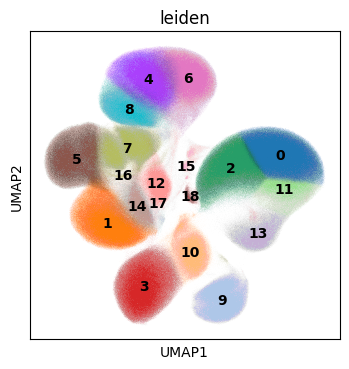

In [16]:
rcParams["figure.figsize"] = (4, 4)
sc.pl.umap(adata_pcs9, 
           color="leiden",
           legend_loc = "on data")

In [42]:
cluster_counts = adata_pcs9.obs['leiden'].value_counts().sort_index()
print("每个Leiden cluster的细胞数量:")
print(cluster_counts)

每个Leiden cluster的细胞数量:
leiden
0     421979
1     357879
2     337114
3     333731
4     308194
5     281558
6     235102
7     202068
8     165036
9     154682
10    137393
11     93107
12     91701
13     89072
14     82681
15     35781
16     15958
17     12371
18      9990
Name: count, dtype: int64


In [15]:
var_names=[ "CD3",
            "CD4",
            "CD8",
            "TCR-gd",
            "CD19",
            "CD27",
            "IgD",
            "HLA-DR",
            "CD56",
            "CD57",
            "CD16",
            "CD14",
            "CD11c",
            "CD1c",
            "CD123",
            "CD38",
            "CD45RA",
            "CCR2",
            "CXCR3",
            "CD69",
            "CD86",
            "Ki-67",
            "CXCL9",
            "CXCL10",
            "MCP-1",
            "TNF-a",
            "IL-4",
            "IL-6",
            "IL-1b",
            "IFN-g",
            "IFN-a",
            "GranzymeB",
            "Arginase-1",
            "H3K27ac",
            "pS6",
            "m6A",
            "pSTAT1",
            "pSTAT3"]

In [22]:
sc.pl.umap(
    adata_pcs9,
    gene_symbols="AB",
    color=var_names,
    ncols=5,
    color_map=mymap,
    vmax="p99",
    save=f"{today}_5k_all_markers.png",
    show=False)
pl.close()

In [23]:
sc.pl.matrixplot(
    adata_pcs9,
    groupby="leiden",
    gene_symbols="AB",
    var_names=var_names,
    dendrogram=True,
    vmin=0,
    cmap=mymap,
    save=f"{today}_5k_all_markers.pdf",
    show=False
)
pl.close()

    using data matrix X directly
Storing dendrogram info using `.uns['dendrogram_leiden']`


In [43]:
cells_to_keep = adata_pcs9.obs['leiden'] != '15'
adata_pcs9_filtered = adata_pcs9[cells_to_keep].copy()

In [44]:
adata_pcs9_filtered.write('/public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU_all_5k/adata_pcs9_cells_rm.h5ad')

In [45]:
cluster1cell = {
    "0": "Monocytes an DCs",
    "1": "CD8 T cells", 
    "2": "Monocytes an DCs",  
    "3": "NK cells",
    "4": "CD4 T cells", 
    "5": "CD8 T cells", 
    "6": "CD4 T cells", 
    "7": "CD8 T cells", 
    "8": "CD4 T cells",
    "9": "B cells",  
    "10": "NK cells",  
    "11": "Monocytes an DCs", 
    "12": "CD4 T cells",
    "13": "Monocytes an DCs", 
    "14": "gd T cells", 
    #"15": "Monocytes an DCs", 
    "16": "CD8 T cells", 
    "17": "CD4 T cells", 
    "18": "Monocytes an DCs", 
}
adata_pcs9_filtered.obs["cell_type_lv1"] = adata_pcs9_filtered.obs["leiden"].map(cluster1cell).copy()

In [46]:
color_dict_1 = {
    "B cells": "#BB493D",
    "CD4 T cells": "#7E5597",
    "CD8 T cells": "#769353",
    "Monocytes an DCs": "#E7BF5E",
    "NK cells": "#538AAD",
    "gd T cells": "#A78B4A" }

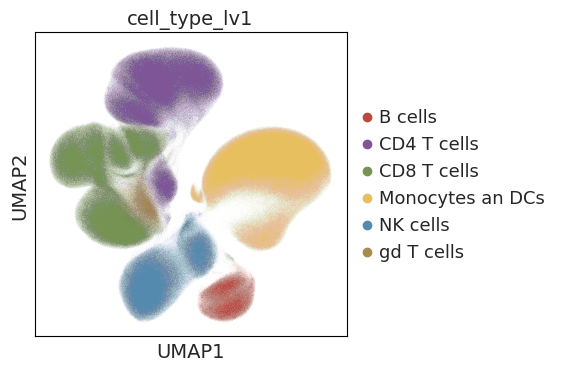

In [190]:
rcParams["figure.figsize"] = (4, 4)
sc.pl.umap(adata_pcs9_filtered,
           color="cell_type_lv1",
           palette=color_dict_1,
           save=f"{today}_cell_type_lv1.pdf")

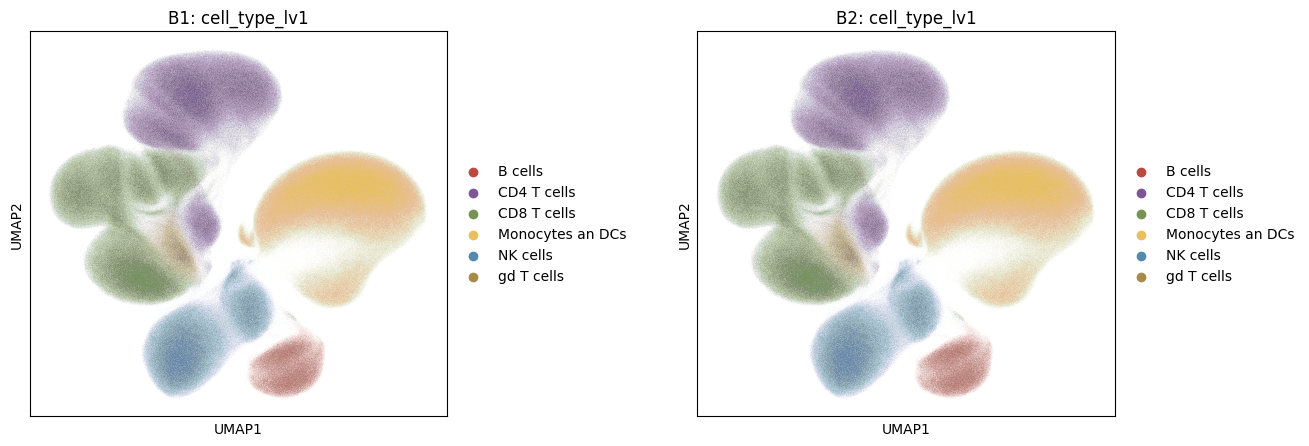

In [48]:
split = adata_pcs9_filtered.obs['Visit'].unique().tolist()
n_split = len(split)
fig,ax = pl.subplots(nrows=1, ncols=n_split, squeeze=False, figsize=(7*n_split, 5))

for i in range(n_split):
    tmp=adata_pcs9_filtered[adata_pcs9_filtered.obs['Visit']==split[i], :]
    sc.pl.umap(adata_pcs9_filtered, color='cell_type_lv1', ax=ax[0,i], show=False)
    ax[0,i].set_title(f"{split[i]}: cell_type_lv1")

pl.subplots_adjust(wspace=0.6)
fig.show()

In [ ]:
pl.style.use('default')
fig, ax = pl.subplots(figsize=(6,4))

sc.pl.umap(adata_pcs9,
           color="cell_type_lv1", 
           legend_loc=None,
           size=20,
           frameon=False,
           ax=ax,
           show=False
          )

for cell_type in adata_pcs9.obs["cell_type_lv1"].unique():
    mask = adata_pcs9.obs["cell_type_lv1"] == cell_type
    x = adata_pcs9.obsm["X_umap"][mask,0]
    y = adata_pcs9.obsm["X_umap"][mask,1]
    x_min, x_max = x.min() - 0.5, x.max() + 0.5
    y_min, y_max = y.min() - 0.5, y.max() + 0.5
    xx, yy = np.mgrid[x_min:x_max:100j, y_min:y_max:100j]
    
    xy_train = np.vstack([x, y]).T
    xy_test = np.vstack([xx.ravel() ,yy.ravel()]).T
    
    kde = KernelDensity(bandwidth=0.6, metric='euclidean')
    kde.fit(xy_train)
    
    Z = np.exp(kde.score_samples(xy_test))
    Z = Z.reshape(xx.shape)
    
    pl.contour(
        xx, yy, Z,
        levels=[Z.max() * 0.1],
        colors='gray',
        linestyles='--',
        linewidths=1.2,
        alpha=0.8
    )

cell_type_counts = adata_pcs9.obs["cell_type_lv1"].value_counts(normalize=True) * 100
for cell_type, percentage in cell_type_counts.items():
    mask = adata_pcs9.obs["cell_type_lv1"] == cell_type
    x = np.median(adata_pcs9.obsm["X_umap"][mask, 0])
    y = np.median(adata_pcs9.obsm["X_umap"][mask, 1])
    ax.text(
        x, y, f"{cell_type} ({percentage:.1f}%)",
        fontsize=8,
        ha="center",
        color="black",
        bbox=dict(facecolor='white',
                  edgecolor='none',
                  alpha=0.7)
    )

pl.savefig('/public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU_all_5k/figures/umap_cell_type_lv1.pdf', format='pdf', bbox_inches='tight')
pl.show()

In [50]:
df_lv1 = pd.crosstab(adata_pcs9_filtered.obs["Visit"], adata_pcs9_filtered.obs["cell_type_lv1"], normalize=0)

In [51]:
df_lv1

cell_type_lv1,B cells,CD4 T cells,CD8 T cells,Monocytes an DCs,NK cells,gd T cells
Visit,,,,,,
B1,0.044687,0.259925,0.293145,0.202017,0.172290,0.027936
B2,0.048234,0.227988,0.221742,0.369764,0.110557,0.021714


In [176]:
sur_names=[ "CD3",
            "CD4",
            "CD8",
            "TCR-gd",
            "CD19",
            "CD27",
            "IgD",
            "HLA-DR",
            "CD56",
            "CD57",
            "CD16",
            "CD14",
            "CD11c",
            "CD1c",
            "CD123" ]

sc.pl.dotplot(adata_pcs9_filtered,
              groupby="cell_type_lv1",
              gene_symbols="AB",
              var_names=sur_names,
              dendrogram=True,
              save=f"{today}_TBNK_markers_lv1.pdf",
              show=False
             )

{'mainplot_ax': <Axes: >,
 'group_extra_ax': <Axes: >,
 'size_legend_ax': <Axes: title={'center': 'Fraction of cells\nin group (%)'}>,
 'color_legend_ax': <Axes: title={'center': 'Mean expression\nin group'}>}

In [170]:
print("所有基因名:")
print(adata_pcs9_filtered.var_names.tolist())

# 或者搜索特定标记
for marker in TBNK_markers:
    matches = [gene for gene in adata_pcs9_filtered.var_names if marker.lower() in gene.lower()]
    if matches:
        print(f"{marker} 的可能匹配: {matches}")

所有基因名:
['112Cd_CD8', '115In_CD4', '141Pr_CD3', '142Nd_EQ2_IgD', '143Nd_CD1c', '144Nd_IFN-a', '145Nd_CXCR3', '146Nd_CXCL9', '147Sm_CD86', '148Nd_H3K27ac', '149Sm_IL-1b', '150Nd_CD57', '151Eu_EQ3_pS6', '152Sm_CCR2', '153Eu_EQ4_TNF-a', '154Sm_IL-4', '155Gd_CD14', '156Gd_CD56', '158Gd_TCR-gd', '159Tb_CD38', '160Gd_CD27', '161Dy_CD123', '162Dy_Ki-67', '163Dy_CXCL10', '164Dy_Arginase-1', '165Ho_EQ5_IL-6', '166Er_MCP-1', '167Er_CD69', '168Er_m6A', '169Tm_GranzymeB', '170Er_CD45RA', '171Yb_HLA-DR', '172Yb_IFN-g', '173Yb_CD11c', '174Yb_CD19', '175Lu_EQ6_pSTAT1', '176Yb_EQ7_pSTAT3', '191Ir_DNA1', '193Ir_DNA2', '195Pt_VIABILITY', '209Bi_CD16']
CD3 的可能匹配: ['141Pr_CD3', '159Tb_CD38']
CD4 的可能匹配: ['115In_CD4', '170Er_CD45RA']
CD8 的可能匹配: ['112Cd_CD8', '147Sm_CD86']
TCR-gd 的可能匹配: ['158Gd_TCR-gd']
CD19 的可能匹配: ['174Yb_CD19']
CD27 的可能匹配: ['160Gd_CD27']
IgD 的可能匹配: ['142Nd_EQ2_IgD']
HLA-DR 的可能匹配: ['171Yb_HLA-DR']
CD56 的可能匹配: ['156Gd_CD56']
CD57 的可能匹配: ['150Nd_CD57']
CD16 的可能匹配: ['209Bi_CD16']
CD14 的可能匹配: ['

In [52]:
cell_type1_counts = adata_pcs9_filtered.obs['cell_type_lv1'].value_counts()
print("各主要细胞类型的细胞数量:")
print(cell_type1_counts)

各主要细胞类型的细胞数量:
cell_type_lv1
Monocytes an DCs    951262
CD8 T cells         857463
CD4 T cells         812404
NK cells            471124
B cells             154682
gd T cells           82681
Name: count, dtype: int64


In [155]:
adata_pcs9_filtered_final.write('/public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU_all_5k/adata_pcs9_cluster1.h5ad')

In [156]:
unique_celltypes = adata_pcs9_filtered_final.obs['cell_type_unified'].unique()
print("=== 所有细胞类型种类 ===")
print(sorted(unique_celltypes))
print(f"\n总共有 {len(unique_celltypes)} 种细胞类型")

=== 所有细胞类型种类 ===
['Arginase-1+ Ki-67+ CD57+ CD16+ CD56+ NK cells', 'Arginase-1+ follicular B cells', 'Arginase-1+ naive CD4 T cells', 'Arginase-1+ naive CD8 T cells', 'CCR2+ central memory CD8 T cells', 'CCR2+ effector memory CD4 T cells', 'CD16+ CD56+ NK cells', 'CD16+ CD8 NKT cells', 'CD16- CD56++ NK cells', 'CD1c+ dendritic cells', 'CD38+ effector CD4 T cells', 'CD4 NKT cells', 'CD4 TEMRA', 'CD56+ CD14+ classical monocytes', 'CD57+ CD16+ CD56+ NK cells', 'CD57+ CD16- CD56++ NK cells', 'CD57+ CD8 TEMRA', 'CD57+ DP T cells', 'CD57+ central memory CD4 T cells', 'CD57+ central memory CD8 T cells', 'CD57+ naive CD4 T cells', 'CD57+ naive CD8 T cells', 'CD69+ Th2 CD4 T cells', 'CD8 NKT cells', 'CD8 T cells', 'CD8 TEMRA', 'CD86+ classical monocytes', 'CD86+ non-classical monocytes', 'CXCL9+ central memory CD4 T cells', 'Central memory CD4 T cells', 'Central memory CD8 T cells', 'Classical monocytes', 'Conventional dendritic cells', 'DP T cells', 'Effector memory CD4 T cell', 'Effector memo

In [167]:
# 定义输出目录
output_dir = "/public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU_all_5k/"
os.makedirs(output_dir, exist_ok=True)

def calculate_celltype_frequency(adata):
    """计算每种细胞类型在每个Sample中的频率"""
    
    # 计算每个Sample中每种细胞类型的数量
    cell_counts = adata.obs.groupby(['Sample', 'cell_type_unified']).size().unstack(fill_value=0)
    
    # 计算每个Sample的总细胞数
    total_cells_per_sample = cell_counts.sum(axis=1)
    
    # 计算频率（百分比）
    frequency_percent = (cell_counts.div(total_cells_per_sample, axis=0) * 100).round(2)
    
    return cell_counts, frequency_percent

# 执行计算
cell_counts, frequency_percent = calculate_celltype_frequency(adata_pcs9_filtered_final)

# 创建合并的输出
def create_combined_output(adata, cell_counts, frequency_percent):
    """合并所有统计信息和元数据输出为CSV"""
    
    # 获取元数据列
    metadata_columns = []
    for col in ['ID', 'Visit', 'Sample']:
        if col in adata.obs.columns:
            metadata_columns.append(col)
    
    print(f"可用的元数据列: {metadata_columns}")
    
    # 获取所有样本的元数据信息
    sample_metadata = adata.obs[metadata_columns].drop_duplicates().set_index('Sample')
    
    combined_stats = []
    
    for sample in cell_counts.index:
        sample_data = {'Sample': sample}
        
        # 添加ID和Visit信息
        if sample in sample_metadata.index:
            sample_info = sample_metadata.loc[sample]
            if 'ID' in sample_info:
                sample_data['ID'] = sample_info['ID']
            if 'Visit' in sample_info:
                sample_data['Visit'] = sample_info['Visit']
        
        # 添加每种细胞类型的统计
        for cell_type in cell_counts.columns:
            count = cell_counts.loc[sample, cell_type]
            freq = frequency_percent.loc[sample, cell_type]
            
            sample_data[f'{cell_type}_Count'] = count
            sample_data[f'{cell_type}_Frequency_%'] = freq
        
        sample_data['Total_Cells'] = cell_counts.loc[sample].sum()
        combined_stats.append(sample_data)
    
    combined_df = pd.DataFrame(combined_stats)
    
    # 重新排列列的顺序
    column_order = ['Sample']
    if 'ID' in metadata_columns:
        column_order.append('ID')
    if 'Visit' in metadata_columns:
        column_order.append('Visit')
    
    # 添加细胞类型计数列
    for cell_type in cell_counts.columns:
        column_order.extend([f'{cell_type}_Count', f'{cell_type}_Frequency_%'])
    
    column_order.append('Total_Cells')
    
    # 只保留实际存在的列
    final_columns = [col for col in column_order if col in combined_df.columns]
    
    combined_df = combined_df[final_columns]
    
    return combined_df

# 输出文件到指定目录
print(f"正在输出文件到: {output_dir}")

# 1. 主要的合并统计表
combined_output = create_combined_output(adata_pcs9_filtered_final, cell_counts, frequency_percent)
combined_output_path = os.path.join(output_dir, 'combined_celltype_statistics.csv')
combined_output.to_csv(combined_output_path, index=False)
print(f"✓ 合并统计表已保存到: {combined_output_path}")

# 2. 细胞计数矩阵
cell_counts_output = cell_counts.copy()
cell_counts_output['Total_Cells'] = cell_counts_output.sum(axis=1)
cell_counts_output_path = os.path.join(output_dir, 'celltype_count_matrix.csv')
cell_counts_output.to_csv(cell_counts_output_path)
print(f"✓ 细胞类型计数矩阵已保存到: {cell_counts_output_path}")

# 3. 频率百分比矩阵
frequency_percent_output = frequency_percent.copy()
frequency_percent_output['Total_Cells'] = cell_counts.sum(axis=1)
frequency_percent_path = os.path.join(output_dir, 'celltype_frequency_matrix.csv')
frequency_percent_output.to_csv(frequency_percent_path)
print(f"✓ 细胞类型频率矩阵已保存到: {frequency_percent_path}")

# 4. 详细的元数据表格
detailed_metadata = adata_pcs9_filtered_final.obs[['ID', 'Visit', 'Sample', 'cell_type_unified']].copy()
detailed_metadata.insert(0, 'Cell_Barcode', detailed_metadata.index)
detailed_metadata_path = os.path.join(output_dir, 'detailed_cell_metadata.csv')
detailed_metadata.to_csv(detailed_metadata_path, index=False)
print(f"✓ 详细细胞元数据已保存到: {detailed_metadata_path}")

# 5. 创建汇总表格（简化版本）
def create_summary_table_simple(adata, cell_counts, frequency_percent):
    """创建简化版本的汇总统计表格"""
    summary_data = []
    
    for cell_type in cell_counts.columns:
        total_count = cell_counts[cell_type].sum()
        freq_series = frequency_percent[cell_type]
        
        # 确保我们处理的是Series而不是单个值
        if isinstance(freq_series, pd.Series):
            avg_freq = freq_series.mean()
            std_freq = freq_series.std()
            median_freq = freq_series.median()
            min_freq = freq_series.min()
            max_freq = freq_series.max()
        else:
            # 如果是单个值
            avg_freq = freq_series
            std_freq = 0
            median_freq = freq_series
            min_freq = freq_series
            max_freq = freq_series
        
        summary_data.append({
            'Cell_Type': cell_type,
            'Total_Count': total_count,
            'Overall_Frequency_%': (total_count / len(adata.obs) * 100).round(2),
            'Average_Frequency_%': round(avg_freq, 2),
            'Std_Frequency_%': round(std_freq, 2),
            'Samples_Detected': (cell_counts[cell_type] > 0).sum(),
            'Min_Frequency_%': round(min_freq, 2),
            'Max_Frequency_%': round(max_freq, 2),
            'Median_Frequency_%': round(median_freq, 2)
        })
    
    return pd.DataFrame(summary_data)

summary_df = create_summary_table_simple(adata_pcs9_filtered_final, cell_counts, frequency_percent)
summary_path = os.path.join(output_dir, 'celltype_summary_statistics.csv')
summary_df.to_csv(summary_path, index=False)
print(f"✓ 细胞类型汇总统计已保存到: {summary_path}")

# 6. 样本级别的汇总
def create_sample_summary(cell_counts):
    """创建样本级别的汇总统计"""
    sample_summary = cell_counts.sum(axis=1).reset_index()
    sample_summary.columns = ['Sample', 'Total_Cells']
    return sample_summary

sample_summary_df = create_sample_summary(cell_counts)
sample_summary_path = os.path.join(output_dir, 'sample_summary.csv')
sample_summary_df.to_csv(sample_summary_path, index=False)
print(f"✓ 样本汇总统计已保存到: {sample_summary_path}")

# 显示基本信息
print(f"\n=== 数据基本信息 ===")
print(f"总样本数: {len(cell_counts)}")
print(f"细胞类型数: {len(cell_counts.columns)}")
print(f"总细胞数: {len(adata_pcs9_filtered_final.obs)}")

print(f"\n=== 文件输出完成 ===")
files = [
    'combined_celltype_statistics.csv',
    'celltype_frequency_matrix.csv', 
    'celltype_count_matrix.csv',
    'detailed_cell_metadata.csv',
    'celltype_summary_statistics.csv',
    'sample_summary.csv'
]

for file in files:
    file_path = os.path.join(output_dir, file)
    if os.path.exists(file_path):
        file_size = os.path.getsize(file_path)
        print(f"✓ {file} ({file_size} bytes)")

# 验证文件内容
print(f"\n=== 文件内容验证 ===")
for file in files:
    file_path = os.path.join(output_dir, file)
    try:
        df = pd.read_csv(file_path)
        print(f"✓ {file}: {df.shape[0]} 行, {df.shape[1]} 列")
    except Exception as e:
        print(f"○ {file}: 读取失败 - {e}")


/tmp/ipykernel_2022892/1650297668.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = adata.obs.groupby(['Sample', 'cell_type_unified']).size().unstack(fill_value=0)


正在输出文件到: /public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU_all_5k/
可用的元数据列: ['ID', 'Visit', 'Sample']
✓ 合并统计表已保存到: /public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU_all_5k/combined_celltype_statistics.csv
✓ 细胞类型计数矩阵已保存到: /public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU_all_5k/celltype_count_matrix.csv
✓ 细胞类型频率矩阵已保存到: /public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU_all_5k/celltype_frequency_matrix.csv
✓ 详细细胞元数据已保存到: /public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU_all_5k/detailed_cell_metadata.csv
✓ 细胞类型汇总统计已保存到: /public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU_all_5k/celltype_summary_statistics.csv
✓ 样本汇总统计已保存到: /public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU_all_5k/sample_summary.csv

=== 数据基本信息 ===
总样本数: 748
细胞类型数: 69
总细胞数: 3309078

=== 文件输出完成 ===
✓ combine

In [168]:
# 定义输出目录
output_dir = "/public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU_all_5k/"
os.makedirs(output_dir, exist_ok=True)

def calculate_celltype_frequency(adata):
    """计算每种细胞类型在每个Sample中的频率"""
    
    # 计算每个Sample中每种细胞类型的数量
    cell_counts = adata.obs.groupby(['Sample', 'cell_type_lv1']).size().unstack(fill_value=0)
    
    # 计算每个Sample的总细胞数
    total_cells_per_sample = cell_counts.sum(axis=1)
    
    # 计算频率（百分比）
    frequency_percent = (cell_counts.div(total_cells_per_sample, axis=0) * 100).round(2)
    
    return cell_counts, frequency_percent

# 执行计算
cell_counts, frequency_percent = calculate_celltype_frequency(adata_pcs9_filtered_final)

# 创建合并的输出
def create_combined_output(adata, cell_counts, frequency_percent):
    """合并所有统计信息和元数据输出为CSV"""
    
    # 获取元数据列
    metadata_columns = []
    for col in ['ID', 'Visit', 'Sample']:
        if col in adata.obs.columns:
            metadata_columns.append(col)
    
    print(f"可用的元数据列: {metadata_columns}")
    
    # 获取所有样本的元数据信息
    sample_metadata = adata.obs[metadata_columns].drop_duplicates().set_index('Sample')
    
    combined_stats = []
    
    for sample in cell_counts.index:
        sample_data = {'Sample': sample}
        
        # 添加ID和Visit信息
        if sample in sample_metadata.index:
            sample_info = sample_metadata.loc[sample]
            if 'ID' in sample_info:
                sample_data['ID'] = sample_info['ID']
            if 'Visit' in sample_info:
                sample_data['Visit'] = sample_info['Visit']
        
        # 添加每种细胞类型的统计
        for cell_type in cell_counts.columns:
            count = cell_counts.loc[sample, cell_type]
            freq = frequency_percent.loc[sample, cell_type]
            
            sample_data[f'{cell_type}_Count'] = count
            sample_data[f'{cell_type}_Frequency_%'] = freq
        
        sample_data['Total_Cells'] = cell_counts.loc[sample].sum()
        combined_stats.append(sample_data)
    
    combined_df = pd.DataFrame(combined_stats)
    
    # 重新排列列的顺序
    column_order = ['Sample']
    if 'ID' in metadata_columns:
        column_order.append('ID')
    if 'Visit' in metadata_columns:
        column_order.append('Visit')
    
    # 添加细胞类型计数列
    for cell_type in cell_counts.columns:
        column_order.extend([f'{cell_type}_Count', f'{cell_type}_Frequency_%'])
    
    column_order.append('Total_Cells')
    
    # 只保留实际存在的列
    final_columns = [col for col in column_order if col in combined_df.columns]
    
    combined_df = combined_df[final_columns]
    
    return combined_df

# 输出文件到指定目录
print(f"正在输出文件到: {output_dir}")

# 1. 主要的合并统计表
combined_output = create_combined_output(adata_pcs9_filtered_final, cell_counts, frequency_percent)
combined_output_path = os.path.join(output_dir, 'combined_celltype_statistics.csv')
combined_output.to_csv(combined_output_path, index=False)
print(f"✓ 合并统计表已保存到: {combined_output_path}")

# 2. 细胞计数矩阵
cell_counts_output = cell_counts.copy()
cell_counts_output['Total_Cells'] = cell_counts_output.sum(axis=1)
cell_counts_output_path = os.path.join(output_dir, 'celltype_count_matrix.csv')
cell_counts_output.to_csv(cell_counts_output_path)
print(f"✓ 细胞类型计数矩阵已保存到: {cell_counts_output_path}")

# 3. 频率百分比矩阵
frequency_percent_output = frequency_percent.copy()
frequency_percent_output['Total_Cells'] = cell_counts.sum(axis=1)
frequency_percent_path = os.path.join(output_dir, 'celltype_frequency_matrix.csv')
frequency_percent_output.to_csv(frequency_percent_path)
print(f"✓ 细胞类型频率矩阵已保存到: {frequency_percent_path}")

# 4. 详细的元数据表格
detailed_metadata = adata_pcs9_filtered_final.obs[['ID', 'Visit', 'Sample', 'cell_type_unified']].copy()
detailed_metadata.insert(0, 'Cell_Barcode', detailed_metadata.index)
detailed_metadata_path = os.path.join(output_dir, 'detailed_cell_metadata.csv')
detailed_metadata.to_csv(detailed_metadata_path, index=False)
print(f"✓ 详细细胞元数据已保存到: {detailed_metadata_path}")

# 5. 创建汇总表格（简化版本）
def create_summary_table_simple(adata, cell_counts, frequency_percent):
    """创建简化版本的汇总统计表格"""
    summary_data = []
    
    for cell_type in cell_counts.columns:
        total_count = cell_counts[cell_type].sum()
        freq_series = frequency_percent[cell_type]
        
        # 确保我们处理的是Series而不是单个值
        if isinstance(freq_series, pd.Series):
            avg_freq = freq_series.mean()
            std_freq = freq_series.std()
            median_freq = freq_series.median()
            min_freq = freq_series.min()
            max_freq = freq_series.max()
        else:
            # 如果是单个值
            avg_freq = freq_series
            std_freq = 0
            median_freq = freq_series
            min_freq = freq_series
            max_freq = freq_series
        
        summary_data.append({
            'Cell_Type': cell_type,
            'Total_Count': total_count,
            'Overall_Frequency_%': (total_count / len(adata.obs) * 100).round(2),
            'Average_Frequency_%': round(avg_freq, 2),
            'Std_Frequency_%': round(std_freq, 2),
            'Samples_Detected': (cell_counts[cell_type] > 0).sum(),
            'Min_Frequency_%': round(min_freq, 2),
            'Max_Frequency_%': round(max_freq, 2),
            'Median_Frequency_%': round(median_freq, 2)
        })
    
    return pd.DataFrame(summary_data)

summary_df = create_summary_table_simple(adata_pcs9_filtered_final, cell_counts, frequency_percent)
summary_path = os.path.join(output_dir, 'celltype_summary_statistics.csv')
summary_df.to_csv(summary_path, index=False)
print(f"✓ 细胞类型汇总统计已保存到: {summary_path}")

# 6. 样本级别的汇总
def create_sample_summary(cell_counts):
    """创建样本级别的汇总统计"""
    sample_summary = cell_counts.sum(axis=1).reset_index()
    sample_summary.columns = ['Sample', 'Total_Cells']
    return sample_summary

sample_summary_df = create_sample_summary(cell_counts)
sample_summary_path = os.path.join(output_dir, 'sample_summary.csv')
sample_summary_df.to_csv(sample_summary_path, index=False)
print(f"✓ 样本汇总统计已保存到: {sample_summary_path}")

# 显示基本信息
print(f"\n=== 数据基本信息 ===")
print(f"总样本数: {len(cell_counts)}")
print(f"细胞类型数: {len(cell_counts.columns)}")
print(f"总细胞数: {len(adata_pcs9_filtered_final.obs)}")

print(f"\n=== 文件输出完成 ===")
files = [
    'combined_celltype_statistics.csv',
    'celltype_frequency_matrix.csv', 
    'celltype_count_matrix.csv',
    'detailed_cell_metadata.csv',
    'celltype_summary_statistics.csv',
    'sample_summary.csv'
]

for file in files:
    file_path = os.path.join(output_dir, file)
    if os.path.exists(file_path):
        file_size = os.path.getsize(file_path)
        print(f"✓ {file} ({file_size} bytes)")

# 验证文件内容
print(f"\n=== 文件内容验证 ===")
for file in files:
    file_path = os.path.join(output_dir, file)
    try:
        df = pd.read_csv(file_path)
        print(f"✓ {file}: {df.shape[0]} 行, {df.shape[1]} 列")
    except Exception as e:
        print(f"○ {file}: 读取失败 - {e}")

/tmp/ipykernel_2022892/2727367162.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cell_counts = adata.obs.groupby(['Sample', 'cell_type_lv1']).size().unstack(fill_value=0)


正在输出文件到: /public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU_all_5k/
可用的元数据列: ['ID', 'Visit', 'Sample']
✓ 合并统计表已保存到: /public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU_all_5k/combined_celltype_statistics.csv
✓ 细胞类型计数矩阵已保存到: /public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU_all_5k/celltype_count_matrix.csv
✓ 细胞类型频率矩阵已保存到: /public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU_all_5k/celltype_frequency_matrix.csv
✓ 详细细胞元数据已保存到: /public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU_all_5k/detailed_cell_metadata.csv
✓ 细胞类型汇总统计已保存到: /public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU_all_5k/celltype_summary_statistics.csv
✓ 样本汇总统计已保存到: /public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU_all_5k/sample_summary.csv

=== 数据基本信息 ===
总样本数: 748
细胞类型数: 6
总细胞数: 3309078

=== 文件输出完成 ===
✓ combined

In [193]:
sc.settings.set_figure_params(dpi=100)

In [189]:
sc.pl.matrixplot(
    adata_pcs9_filtered_final,
    groupby="cell_type_unified",
    gene_symbols="AB",
    var_names=var_names,
    dendrogram=True,
    vmin=0,
    cmap=mymap,
    save=f"{today}_5k_unified_all_markers.pdf",
    show=False
)
pl.close()

    using data matrix X directly
Storing dendrogram info using `.uns['dendrogram_cell_type_unified']`


In [4]:
adata_pcs9_filtered_final = ad.read_h5ad('/public/users/yuxuanjing/Mass_cytometry/pk/Formal/20250820_data_autodebarcode/CPU_all_5k/adata_pcs9_cluster1.h5ad')

In [6]:
metadata_path = "/public/users/yuxuanjing/FB_cohort/Metadata.csv"  # 替换为你的Metadata文件路径
metadata = pd.read_csv(metadata_path)  # 如果是Excel文件，使用 pd.read_excel()

In [7]:
# 2. 提取adata_pcs9_filtered_final中的ID列
obs_ids = adata_pcs9_filtered_final.obs['ID'].unique()
print("adata_pcs9_filtered_final中的ID数量:", len(obs_ids))
print("前10个ID:", obs_ids[:10])

# 3. 检查Metadata中的ID列名（可能需要调整）
# 通常ID列名可能是 'ID', 'SampleID', 'PatientID' 等
id_column = None
for col in metadata.columns:
    if col.upper() in ['ID', 'SAMPLEID', 'PATIENTID', 'SAMPLE_ID', 'PATIENT_ID']:
        id_column = col
        print(f"找到ID列: {col}")
        break

if id_column is None:
    print("Metadata列名:", metadata.columns.tolist())
    # 手动指定ID列名
    id_column = input("请指定ID列名: ")

# 4. 匹配ID并筛选Metadata
matched_metadata = metadata[metadata[id_column].isin(obs_ids)]
print(f"匹配到的样本数量: {len(matched_metadata)}")
print(f"未匹配到的样本数量: {len(metadata) - len(matched_metadata)}")

# 5. 创建FB_adata对象（复制原始数据）
FB_adata = adata_pcs9_filtered_final.copy()

# 6. 将匹配的Metadata信息添加到obs中
# 首先确保metadata的ID列与obs的ID列对应
metadata_to_add = matched_metadata.set_index(id_column)

# 只添加obs中不存在的列
existing_cols = set(FB_adata.obs.columns)
new_cols = [col for col in metadata_to_add.columns if col not in existing_cols]

if new_cols:
    # 将metadata信息合并到obs中
    FB_adata.obs = FB_adata.obs.merge(
        metadata_to_add[new_cols], 
        left_on='ID', 
        right_index=True, 
        how='left'
    )
    print(f"成功添加了 {len(new_cols)} 个新列: {new_cols}")
else:
    print("没有新的列可以添加")


adata_pcs9_filtered_final中的ID数量: 374
前10个ID: ['FB295', 'FB010', 'FB370', 'FB332', 'FB097', 'FB374', 'FB256', 'FB143', 'FB222', 'FB164']
Categories (374, object): ['FB001', 'FB002', 'FB003', 'FB004', ..., 'FB373', 'FB374', 'FB375', 'FB376']
找到ID列: ID
匹配到的样本数量: 374
未匹配到的样本数量: 2
成功添加了 5 个新列: ['Vaccination', 'Age', 'Gender', 'BMI', 'Infection']


In [25]:
FB_adata.obs

,ID,Visit,Sample,Center,Event_length,Offset,Residual,beadDist,Time,Width,...,CD8_type_lv1,mono_type_lv1,NK_type_lv1,gd_type_lv1,cell_type_unified,Vaccination,Age,Gender,BMI,Infection
46383-0,FB295,B1,FB295_B1,1352.289551,31.0,1003.482788,6180.243164,46.040245,3.681528e+06,117.173531,...,Effector memory CD8 T cells,NaN,NaN,NaN,Effector memory CD8 T cells,RQ3027,31,Male,24.221453,Inf
27988-0,FB295,B1,FB295_B1,1408.513550,28.0,950.918640,5231.753906,45.519234,2.233665e+06,87.247993,...,NaN,NaN,Ki-67+ CD57+ CD16+ CD56+ NK cells,NaN,Ki-67+ CD57+ CD16+ CD56+ NK cells,RQ3027,31,Male,24.221453,Inf
3531-0,FB295,B1,FB295_B1,2093.395020,46.0,801.505615,4914.592285,42.152382,2.788776e+05,199.413193,...,CD8 TEMRA,NaN,NaN,NaN,CD8 TEMRA,RQ3027,31,Male,24.221453,Inf
27720-0,FB295,B1,FB295_B1,1728.629395,32.0,870.340759,5214.727539,45.642986,2.212340e+06,121.659821,...,NaN,IL-6+ classical monocytes,NaN,NaN,IL-6+ classical monocytes,RQ3027,31,Male,24.221453,Inf
15773-0,FB295,B1,FB295_B1,1783.229980,40.0,768.399170,5037.709961,50.156551,1.250352e+06,141.074005,...,NaN,Classical monocytes,NaN,NaN,Classical monocytes,RQ3027,31,Male,24.221453,Inf
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24419-747,FB019,B2,FB019_B2,1939.018799,48.0,646.089478,6938.404297,NaN,1.533891e+06,175.598923,...,NaN,Classical monocytes,NaN,NaN,Classical monocytes,RQ3013,22,Male,27.459822,Inf
1764-747,FB019,B2,FB019_B2,3308.087646,68.0,842.552368,5463.770996,NaN,1.033022e+05,433.375580,...,NaN,NaN,NaN,NaN,Th2 CD4 T cells,RQ3013,22,Male,27.459822,Inf
39804-747,FB019,B2,FB019_B2,1676.521484,41.0,737.594055,4492.305664,NaN,2.589961e+06,213.615479,...,NaN,NaN,NaN,NaN,Central memory CD4 T cells,RQ3013,22,Male,27.459822,Inf
27093-747,FB019,B2,FB019_B2,1919.150513,42.0,460.194214,4076.573486,NaN,1.708344e+06,180.043289,...,CCR2+ central memory CD8 T cells,NaN,NaN,NaN,CCR2+ central memory CD8 T cells,RQ3013,22,Male,27.459822,Inf


In [19]:
#### 330w cells，文件太大需要先合并再计算MFI,第二个cell就是计算
# 取出感兴趣的marker的索引
markers_of_interest = var_names

# 确认FB_adata.var中AB列对应的marker名称
# 这里假设FB_adata.var['AB']就是marker名称，与var_names对应

# 找到FB_adata.var中AB列对应的marker在var_names中的索引
marker_mask = FB_adata.var['AB'].isin(markers_of_interest)
selected_markers = FB_adata.var[marker_mask].index

# 取表达矩阵对应这些marker的列
# FB_adata.X是细胞x基因矩阵，这里选对应列
expr_mat = FB_adata[:, selected_markers].X

# 如果是稀疏矩阵，转成密集数组
if hasattr(expr_mat, "toarray"):
    expr_mat = expr_mat.toarray()

# 构建DataFrame，行为细胞，列为marker名称（这里用AB列）
expr_df = pd.DataFrame(expr_mat, index=FB_adata.obs_names, columns=FB_adata.var.loc[selected_markers, 'AB'])

# 加入obs中的分组信息
group_df = FB_adata.obs[['Sample', 'cell_type_unified','ID','Visit']]

# 合并表达量和分组信息
expr_df = expr_df.join(group_df)

# 按Sample和cell_type_unified分组，计算median表达量
median_expr = expr_df

In [33]:
# 筛选FB_adata.var中AB列对应的marker是否在感兴趣列表中
marker_mask = FB_adata.var['AB'].isin(markers_of_interest)

# 获取满足条件marker在FB_adata.var中的索引
selected_markers = FB_adata.var[marker_mask].index

# 取出表达矩阵对应的列（细胞 x marker）
expr_mat = FB_adata[:, selected_markers].X

# 如果是稀疏矩阵，转成密集数组
if hasattr(expr_mat, "toarray"):
    expr_mat = expr_mat.toarray()

# 构建表达量DataFrame，行为细胞，列为marker名称 (用AB列对应名称)
expr_df = pd.DataFrame(expr_mat, index=FB_adata.obs_names, columns=FB_adata.var.loc[selected_markers, 'AB'])

# 取obs中的分组信息（包含所有需要的列）
group_df = FB_adata.obs[['Sample', 'cell_type_unified', 'ID', 'Visit', 'Infection', 'Vaccination']]

# 合并表达量和分组信息，行索引对齐
merged_df = expr_df.join(group_df)

# 按Sample和cell_type_unified分组，计算每个marker的中位数表达量
median_expr_by_group = merged_df.groupby(['Sample', 'cell_type_unified'])[var_names].median().reset_index()

# 为了保留Infection、Vaccination等信息，需要合并回原始的分组信息
# 获取每个Sample对应的Infection、Vaccination、ID、Visit信息（假设这些信息在Sample级别是一致的）
sample_info = FB_adata.obs[['Sample', 'Infection', 'Vaccination', 'ID', 'Visit']].drop_duplicates()

# 合并中位数表达量与样本信息
median_expr = median_expr_by_group.merge(sample_info, on='Sample', how='left')

/tmp/ipykernel_3446376/3588074514.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_expr_by_group = merged_df.groupby(['Sample', 'cell_type_unified'])[var_names].median().reset_index()


In [40]:
output_path = "/public/users/yuxuanjing/FB_cohort/All_pre_analysis/CYTOF_38markers_unified_celltypes_median_expr_data.csv"
median_expr.to_csv(output_path, index=False)

In [41]:
epi_markers=["H3K27ac",
            "m6A"]

In [54]:
sc.settings.set_figure_params(dpi=80)

In [55]:
unique_visits = FB_adata.obs['Visit'].unique()
unique_infections = FB_adata.obs['Infection'].unique()

# 创建更大的子图网格：行=Visit数，列=Infection数×Marker数
fig, axes = pl.subplots(len(unique_visits), len(unique_infections) * len(epi_markers), 
                        figsize=(5*len(unique_infections)*len(epi_markers), 5*len(unique_visits)))

for i, visit in enumerate(unique_visits):
    for j, infection in enumerate(unique_infections):
        for k, marker in enumerate(epi_markers):
            col_idx = j * len(epi_markers) + k
            
            # 筛选对应分组的细胞
            mask = (FB_adata.obs['Visit'] == visit) & (FB_adata.obs['Infection'] == infection)
            subset_adata = FB_adata[mask]
            
            if len(subset_adata) > 0:
                if len(unique_visits) > 1:
                    ax = axes[i, col_idx]
                else:
                    ax = axes[col_idx]
                
                sc.pl.umap(
                    subset_adata,
                    gene_symbols="AB",
                    color=marker,
                    color_map=mymap,
                    vmax="p99",
                    ax=ax,
                    show=False,
                    title=f"{marker}, {visit}, {infection}"
                )

pl.tight_layout()
pl.savefig("/public/users/yuxuanjing/FB_cohort/All_pre_analysis/figures/python/epi_markers_umap.pdf", 
           dpi=80)
pl.close()